# Unidad 5: Aprendizaje no supervisado.  #

# _Construcción del dataset_

Armemos un dataset de chocolates.

In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 10

# Chocolate negro

negro = pd.DataFrame({
    "Cacao":      np.random.normal(80, 3, n),
    "Azucar":     np.random.normal(20, 2, n),
    "Grasa":      np.random.normal(40, 2, n),
    "Proteina":   np.random.normal(8, 0.5, n),
    "Calorias":   np.random.normal(550, 12, n),
    "Precio":     np.random.normal(7.5, 0.5, n),
    "Tipo":       "Negro"
})

# Chocolate con leche

leche = pd.DataFrame({
    "Cacao":      np.random.normal(38, 3, n),
    "Azucar":     np.random.normal(50, 3, n),
    "Grasa":      np.random.normal(31, 2, n),
    "Proteina":   np.random.normal(7, 0.5, n),
    "Calorias":   np.random.normal(540, 10, n),
    "Precio":     np.random.normal(4.2, 0.4, n),
    "Tipo":       "Leche"
})

# Chocolate blanco

blanco = pd.DataFrame({
    "Cacao":      np.random.normal(20, 2, n),
    "Azucar":     np.random.normal(65, 3, n),
    "Grasa":      np.random.normal(34, 2, n),
    "Proteina":   np.random.normal(6, 0.4, n),
    "Calorias":   np.random.normal(555, 10, n),
    "Precio":     np.random.normal(4.8, 0.4, n),
    "Tipo":       "Blanco"
})

# Chocolate con frutos secos

frutos = pd.DataFrame({
    "Cacao":      np.random.normal(60, 3, n),
    "Azucar":     np.random.normal(35, 2, n),
    "Grasa":      np.random.normal(60, 2, n),
    "Proteina":   np.random.normal(13, 0.6, n),
    "Calorias":   np.random.normal(640, 12, n),
    "Precio":     np.random.normal(7, 0.5, n),
    "Tipo":       "Frutos secos"
})

# Chocolate sin azúcar

sinazucar = pd.DataFrame({
    "Cacao":      np.random.normal(75, 2, n),   
    "Azucar":     np.random.normal(2, 1, n),    
    "Grasa":      np.random.normal(35, 2, n),   
    "Proteina":   np.random.normal(8, 0.5, n),   
    "Calorias":   np.random.normal(500, 10, n),  
    "Precio":     np.random.normal(9.5, 0.5, n), 
    "Tipo":       "Sin azúcar"
})

# Dataset

chocolates = pd.concat(
    [negro, leche, blanco, frutos, sinazucar],
    ignore_index=True
)

# Mezclamos las filas
chocolates = chocolates.sample(frac=1, random_state=42).reset_index(drop=True)

# Agregamos ID
chocolates.insert(0, "ID", range(1, len(chocolates)+1))

print(chocolates.head(10))

print("La variable 'Tipo' representa el tipo de chocolate y no se utilizará durante el entrenamiento del algoritmo de clustering. Se conservará únicamente para evaluar qué tan bien los clusters recuperan los grupos originales.")

# Guardamos
chocolates.to_csv("dataset_chocolates.csv", index=False)


   ID      Cacao     Azucar      Grasa   Proteina    Calorias    Precio  \
0   1  34.411380  54.693931  29.963460   6.836169  531.977227  5.185297   
1   2  55.455458  32.714059  67.705463  13.049124  648.155173  7.426217   
2   3  61.877002  34.106970  60.715575  13.342534  667.775903  6.634817   
3   4  74.330998   1.515766  32.504434   8.231052  480.479122  9.153545   
4   5  41.010599  49.102978  31.657502   7.130528  541.745778  3.732529   
5   6  78.530908   2.443819  34.119911   8.034901  502.809919  9.906431   
6   7  18.018927  62.650240  31.526099   6.746310  563.220602  4.805201   
7   8  24.380911  69.649803  35.563646   5.714259  559.127809  5.130873   
8   9  56.787323  35.428187  62.166102  13.572401  648.235122  7.022786   
9  10  36.064641  44.037293  32.026535   6.882706  539.255541  4.500773   

           Tipo  
0         Leche  
1  Frutos secos  
2  Frutos secos  
3    Sin azúcar  
4         Leche  
5    Sin azúcar  
6        Blanco  
7        Blanco  
8  Frutos se

Exploremos un poco más nuestro dataset.

In [6]:
chocolates.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        50 non-null     int64  
 1   Cacao     50 non-null     float64
 2   Azucar    50 non-null     float64
 3   Grasa     50 non-null     float64
 4   Proteina  50 non-null     float64
 5   Calorias  50 non-null     float64
 6   Precio    50 non-null     float64
 7   Tipo      50 non-null     str    
dtypes: float64(6), int64(1), str(1)
memory usage: 3.3 KB


In [7]:
print(chocolates["Tipo"].value_counts())

Tipo
Leche           10
Frutos secos    10
Sin azúcar      10
Blanco          10
Negro           10
Name: count, dtype: int64


In [8]:
chocolates.describe()

,ID,Cacao,Azucar,Grasa,Proteina,Calorias,Precio
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,54.749170,33.853905,39.899522,8.393869,557.004825,6.678476
std,14.57738,23.216914,22.300383,11.308485,2.531724,46.997494,1.979208
min,1.00000,17.196298,0.480630,28.517465,5.523479,480.479122,3.432492
25%,13.25000,36.189100,17.375129,32.230896,6.812002,532.047355,4.778170
50%,25.50000,59.555562,35.211934,34.962416,7.496784,546.589966,7.051589
75%,37.75000,75.959972,52.120327,40.200148,8.539005,564.280471,7.982239
max,50.00000,84.737638,69.649803,67.705463,13.681339,667.775903,9.949800


In [9]:
chocolates.isnull().sum()

ID          0
Cacao       0
Azucar      0
Grasa       0
Proteina    0
Calorias    0
Precio      0
Tipo        0
dtype: int64

En la exploración, notamos que no hay datos faltantes y que las variables tienen escalas distintas. Es por eso que más adelante necesitaremos estandarizar.

Antes, hagamos algunos gráficos para ver las relaciones entre variables. 

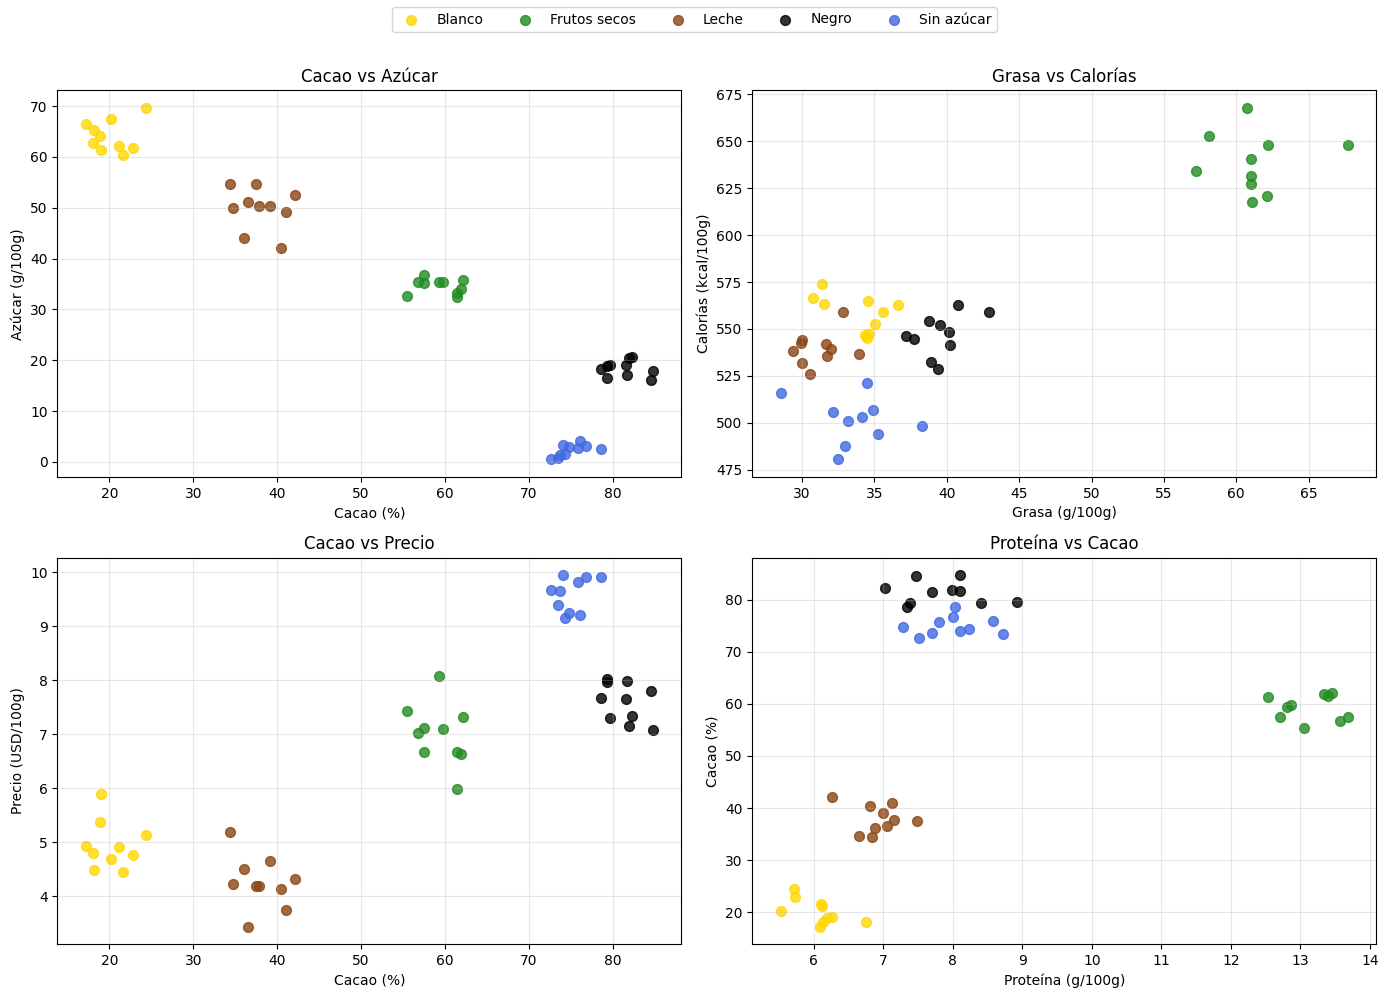

In [10]:
import matplotlib.pyplot as plt

# Colores para cada tipo de chocolate
colores = {
    "Negro": "black",
    "Leche": "saddlebrown",
    "Blanco": "gold",
    "Frutos secos": "forestgreen",
    "Sin azúcar": "royalblue"
}

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# ==========================
# 1. Cacao vs Azúcar
# ==========================
for tipo, grupo in chocolates.groupby("Tipo"):
    axs[0, 0].scatter(
        grupo["Cacao"],
        grupo["Azucar"],
        color=colores[tipo],
        label=tipo,
        s=50,
        alpha=0.8
    )

axs[0, 0].set_title("Cacao vs Azúcar")
axs[0, 0].set_xlabel("Cacao (%)")
axs[0, 0].set_ylabel("Azúcar (g/100g)")
axs[0, 0].grid(alpha=0.3)

# ==========================
# 2. Grasa vs Calorías
# ==========================
for tipo, grupo in chocolates.groupby("Tipo"):
    axs[0, 1].scatter(
        grupo["Grasa"],
        grupo["Calorias"],
        color=colores[tipo],
        s=50,
        alpha=0.8
    )

axs[0, 1].set_title("Grasa vs Calorías")
axs[0, 1].set_xlabel("Grasa (g/100g)")
axs[0, 1].set_ylabel("Calorías (kcal/100g)")
axs[0, 1].grid(alpha=0.3)

# ==========================
# 3. Cacao vs Precio
# ==========================
for tipo, grupo in chocolates.groupby("Tipo"):
    axs[1, 0].scatter(
        grupo["Cacao"],
        grupo["Precio"],
        color=colores[tipo],
        s=50,
        alpha=0.8
    )

axs[1, 0].set_title("Cacao vs Precio")
axs[1, 0].set_xlabel("Cacao (%)")
axs[1, 0].set_ylabel("Precio (USD/100g)")
axs[1, 0].grid(alpha=0.3)

# ==========================
# 4. Proteína vs Cacao
# ==========================
for tipo, grupo in chocolates.groupby("Tipo"):
    axs[1, 1].scatter(
        grupo["Proteina"],
        grupo["Cacao"],
        color=colores[tipo],
        s=50,
        alpha=0.8
    )

axs[1, 1].set_title("Proteína vs Cacao")
axs[1, 1].set_xlabel("Proteína (g/100g)")
axs[1, 1].set_ylabel("Cacao (%)")
axs[1, 1].grid(alpha=0.3)

# Leyenda única para toda la figura
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

En los gráficos de dispersión notamos que las combinacions Cacao vs Precio y Cacao vs Azúcar serán útiles para distinguir entre grupos. 

# *Procesamiento* 

Primero, vamos a quitarnos las variables ID y Tipo. Recordemos que Tipo era una columna que habíamos agregado para comparar resultados.

In [11]:
df = chocolates.drop(columns=["ID", "Tipo"])

Ahora, escalemos los datos. 

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

df_scaled=pd.DataFrame(df_scaled, columns=df.columns)

In [13]:
df_scaled.head(10)

,Cacao,Azucar,Grasa,Proteina,Calorias,Precio
0,-0.884884,0.944002,-0.887558,-0.621519,-0.537937,-0.762092
1,0.030730,-0.051632,2.483820,1.857437,1.959163,0.381633
2,0.310127,0.011463,1.859435,1.974507,2.380886,-0.022283
3,0.851992,-1.464838,-0.660581,-0.064964,-1.644825,1.263231
4,-0.597756,0.690746,-0.736235,-0.504070,-0.327974,-1.503559
5,1.034728,-1.422800,-0.516275,-0.143227,-1.164852,1.647490
6,-1.598109,1.304403,-0.747972,-0.657372,0.133600,-0.956086
7,-1.321303,1.621466,-0.387311,-1.069158,0.045631,-0.789869
8,0.088679,0.071311,1.989006,2.066224,1.960882,0.175730
9,-0.812951,0.461282,-0.703270,-0.602950,-0.381499,-1.111461


# *Clustering*

Supongamos que no sabemos que nuestro dataset tiene 5 categorías. Usemos el método del codo para ver cual es el k ideal. 

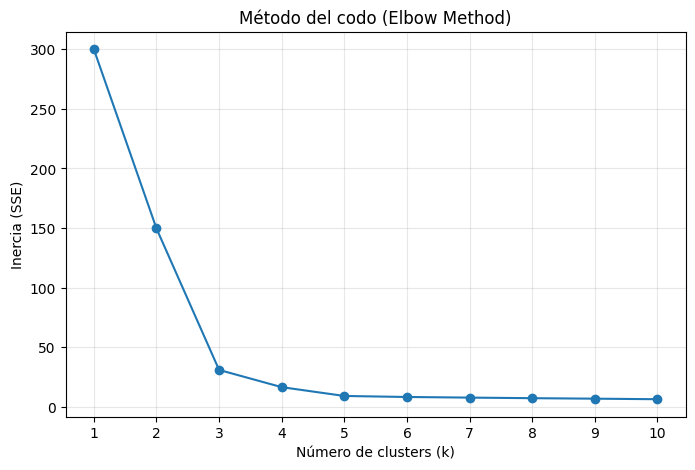

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# =========================
# 4. Gráfico
# =========================
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker="o")
plt.title("Método del codo (Elbow Method)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (SSE)")
plt.xticks(K)
plt.grid(alpha=0.3)
plt.show()

Podemos como la inercia baja muy rápidamente entre $k=1$ y $k=3$. A partir de ese valor, la reudcción de la inercia es bastante menor, indicando que agregar más clusters aporta poca mejora en la compactación de grupos.

Usemos ahora el coeficiente de la silueta para confirmar que $k=3$ sea el valor de $k$ adecuado. 

k = 2: Silhouette = 0.535
k = 3: Silhouette = 0.739
k = 4: Silhouette = 0.715
k = 5: Silhouette = 0.654
k = 6: Silhouette = 0.540
k = 7: Silhouette = 0.445
k = 8: Silhouette = 0.461
k = 9: Silhouette = 0.354
k = 10: Silhouette = 0.357


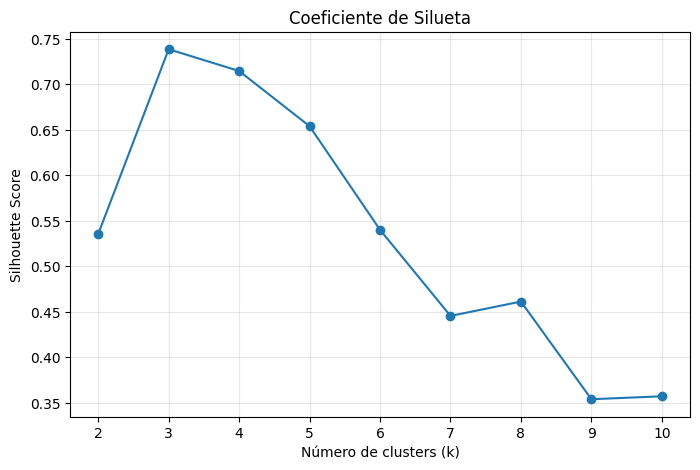


El mejor valor de k según Silhouette es: 3
Coeficiente de Silueta máximo: 0.739


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Rango de valores de k a evaluar
K = range(2, 11)

silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

    print(f"k = {k}: Silhouette = {score:.3f}")

# Gráfico
plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, marker='o')
plt.title("Coeficiente de Silueta")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(K)
plt.grid(alpha=0.3)
plt.show()

# Mejor k según silhouette
mejor_k = K[silhouette_scores.index(max(silhouette_scores))]
print(f"\nEl mejor valor de k según Silhouette es: {mejor_k}")
print(f"Coeficiente de Silueta máximo: {max(silhouette_scores):.3f}")

Observamos como el coeficiente de silueta alcanza su máximo en $k=3$ con un coeficiente de $0.739$, lo que indica una muy buena separación entre clusters. Al aumentar los clusters, el coeficiente disminuye, indicando que más particiones genera grupos menos diferenciados.

Esto puede ocurrir aunque hayamos armado nuestro dataset con 5 categorías porque puede haber algunas muy parecidas entre ellas.

Ahora, usamos el método de K-Means con $k=3$. 

In [16]:
from sklearn.cluster import KMeans

# Entrenamiento del modelo
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Asignación de clusters
chocolates["Cluster"] = kmeans.fit_predict(df_scaled)

# Mostrar las primeras filas
print(chocolates.head(10))

#Chocolates en cada cluster
print(chocolates["Cluster"].value_counts().sort_index())

# Centroides
centroides = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df.columns
)

print(centroides)

# Centroides desescalados
centroides_originales = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns
)

print(centroides_originales.round(2))

   ID      Cacao     Azucar      Grasa   Proteina    Calorias    Precio  \
0   1  34.411380  54.693931  29.963460   6.836169  531.977227  5.185297   
1   2  55.455458  32.714059  67.705463  13.049124  648.155173  7.426217   
2   3  61.877002  34.106970  60.715575  13.342534  667.775903  6.634817   
3   4  74.330998   1.515766  32.504434   8.231052  480.479122  9.153545   
4   5  41.010599  49.102978  31.657502   7.130528  541.745778  3.732529   
5   6  78.530908   2.443819  34.119911   8.034901  502.809919  9.906431   
6   7  18.018927  62.650240  31.526099   6.746310  563.220602  4.805201   
7   8  24.380911  69.649803  35.563646   5.714259  559.127809  5.130873   
8   9  56.787323  35.428187  62.166102  13.572401  648.235122  7.022786   
9  10  36.064641  44.037293  32.026535   6.882706  539.255541  4.500773   

           Tipo  Cluster  
0         Leche        1  
1  Frutos secos        2  
2  Frutos secos        2  
3    Sin azúcar        0  
4         Leche        1  
5    Sin azú

In [17]:
pd.crosstab(chocolates["Tipo"], chocolates["Cluster"])

Cluster,0,1,2
Tipo,,,
Blanco,0,10,0
Frutos secos,0,0,10
Leche,0,10,0
Negro,10,0,0
Sin azúcar,10,0,0


Se entrenó un modelo K-Means con $k=3$, que habíamos elegido con el método del codo y el coeficiente de silueta. Vemos que el modelo agrupó en 3 grupos con distintas características: 
- Alto porcentaje de cacao y bajo contenido en azúcar, que corresponden a los chocolates negros y sin azúcar.
- Bajo porcentaje de cacao y alto en azúcar, correspondientes a los chocolates blancos y con leche.
- Altos valores de grasa, proteína y calorías, coincidiendo con los chocolates con frutos secos. 

Hagamos DBSCAN para comparar.

Primero, hacemos el gráfico de distancias al k-ésimo vecino para elegir un buen `eps` 

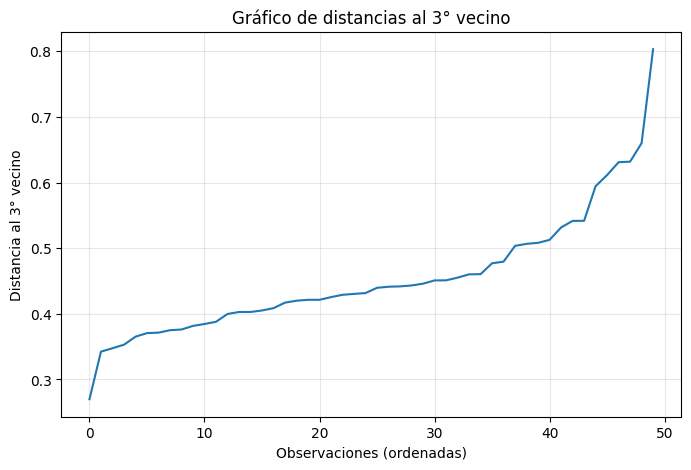

In [18]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Elegimos min_samples
min_samples = 3

# Calculamos las distancias al k-ésimo vecino
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_scaled)

distances, indices = neighbors_fit.kneighbors(df_scaled)

# Nos quedamos con la distancia al tercer vecino
k_distances = np.sort(distances[:, min_samples-1])

# Gráfico
plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title(f"Gráfico de distancias al {min_samples}° vecino")
plt.xlabel("Observaciones (ordenadas)")
plt.ylabel(f"Distancia al {min_samples}° vecino")
plt.grid(alpha=0.3)
plt.show()

A diferencia de K-Means, DBSCAN no necesita que le especifiquemos la cantidad de clusters. Usamos los parámetros `eps` (el radio de cada vecindario) y `min_samples` (la cantidad mínima de vecinos necesarios para formar un cluster).

A partir del gráfico anterior, construido con `min_samples = 3`, elegimos `eps = 0.65`, que es el valor a partir del cual la curva se incrementa de manera pronunciada. 

Ahora sí, aplicamos DBSCAN.

In [19]:
from sklearn.cluster import DBSCAN

# Entrenamiento del modelo
dbscan = DBSCAN(eps=0.65, min_samples=3)

# Asignación de clusters
chocolates["Cluster_DBSCAN"] = dbscan.fit_predict(df_scaled)

# Cantidad de observaciones por cluster
print(chocolates["Cluster_DBSCAN"].value_counts().sort_index())

# Número de clusters encontrados
n_clusters = len(set(chocolates["Cluster_DBSCAN"])) - (1 if -1 in chocolates["Cluster_DBSCAN"].values else 0)
n_ruido = (chocolates["Cluster_DBSCAN"] == -1).sum()

print(f"\nClusters encontrados: {n_clusters}")
print(f"Observaciones clasificadas como ruido: {n_ruido}")

# Comparación con los tipos originales
print("\nTabla de contingencia:")
print(pd.crosstab(chocolates["Tipo"], chocolates["Cluster_DBSCAN"]))

Cluster_DBSCAN
0    10
1    10
2    10
3    10
4    10
Name: count, dtype: int64

Clusters encontrados: 5
Observaciones clasificadas como ruido: 0

Tabla de contingencia:
Cluster_DBSCAN   0   1   2   3   4
Tipo                              
Blanco           0   0   0  10   0
Frutos secos     0  10   0   0   0
Leche           10   0   0   0   0
Negro            0   0   0   0  10
Sin azúcar       0   0  10   0   0


Notamos que usando este algoritmo, encontramos las 5 clases que nos habíamos construido en la creación del dataset. Esto ocurre ya que, utiliza como criterio la densidad. Existen 5 regiones densas separadas, que pueden estar cerca entre sí, pero DBSCAN las identifica como 5 clusters diferentes.

# _Representación_

Como queremos visualizar los resultados obtenidos, usamos la técnica de _Análisis de Componentes Principales_ (PCA) que permite reducir la dimensión del conjunto de datos proyectando las observaciones sobre un pequeño número de componentes que conservan gran parte de la variabilidad de las variables originales. 

In [20]:
from sklearn.decomposition import PCA
import pandas as pd

# PCA a dos componentes
pca = PCA(n_components=2)

componentes = pca.fit_transform(df_scaled)

# Agregar las componentes al DataFrame
chocolates["PC1"] = componentes[:, 0]
chocolates["PC2"] = componentes[:, 1]

# Varianza explicada
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print(f"\nVarianza total explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Varianza explicada por cada componente:
[0.51581771 0.42766624]

Varianza total explicada: 94.35%


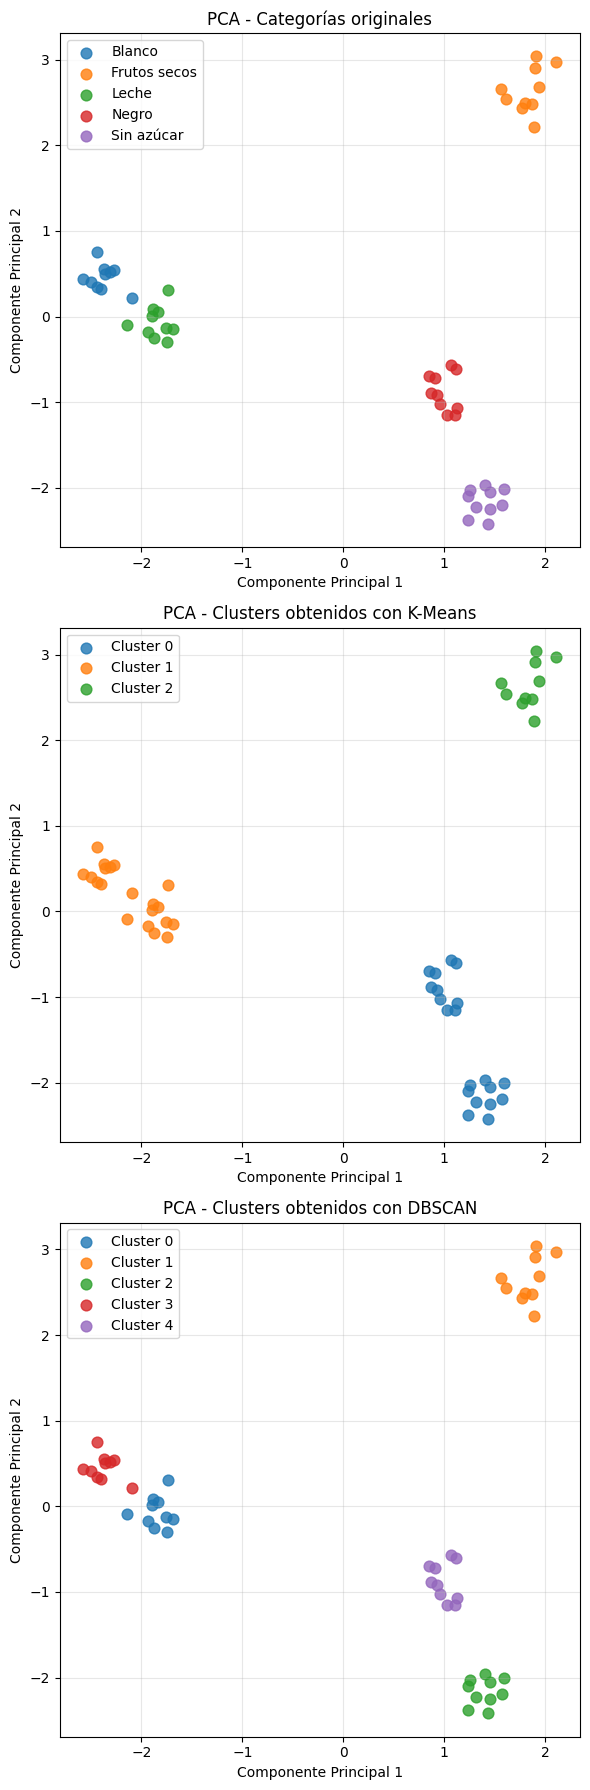

In [21]:
fig, axs = plt.subplots(3, 1, figsize=(6,18))

# Gráfico para las categorías originales
for tipo, grupo in chocolates.groupby("Tipo"):
    axs[0].scatter(grupo["PC1"], grupo["PC2"], label=tipo, s=60, alpha=0.8)
axs[0].set_title("PCA - Categorías originales")
axs[0].set_xlabel("Componente Principal 1")
axs[0].set_ylabel("Componente Principal 2")
axs[0].legend()
axs[0].grid(alpha=0.3)

# Gráfico para los clusters de K-Means
for cluster, grupo in chocolates.groupby("Cluster"):
    axs[1].scatter(grupo["PC1"], grupo["PC2"], label=f"Cluster {cluster}", s=60, alpha=0.8)
axs[1].set_title("PCA - Clusters obtenidos con K-Means")
axs[1].set_xlabel("Componente Principal 1")
axs[1].set_ylabel("Componente Principal 2")
axs[1].legend()
axs[1].grid(alpha=0.3)

# Gráfico para los clusters de DBSCAN
for cluster, grupo in chocolates.groupby("Cluster_DBSCAN"):
    nombre = "Ruido" if cluster == -1 else f"Cluster {cluster}"
    axs[2].scatter(grupo["PC1"], grupo["PC2"], label=nombre, s=60, alpha=0.8)
axs[2].set_title("PCA - Clusters obtenidos con DBSCAN")
axs[2].set_xlabel("Componente Principal 1")
axs[2].set_ylabel("Componente Principal 2")
axs[2].legend()
axs[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Al aplicar PCA, observamos que las dos primeras componentes explican el $94.35 \% $ de la varianza del dataset. Esto indica que la estructura de datos puede representarse adecuadamente en un espacio de dos dimensiones, sin pérdida significativa de información. 

            PC1    PC2
Cacao     0.496 -0.238
Azucar   -0.469  0.343
Grasa     0.351  0.480
Proteina  0.412  0.404
Calorias  0.130  0.594
Precio    0.473 -0.280


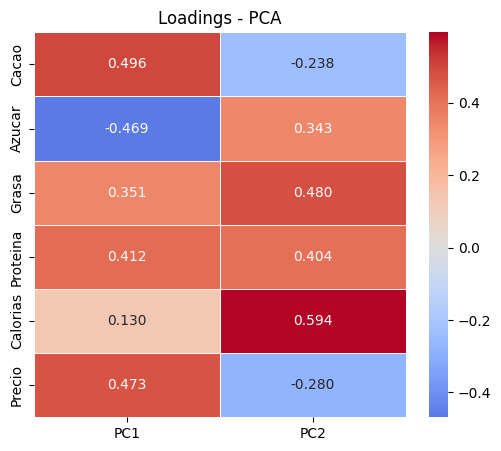

In [22]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(df_scaled)

# Loadings de las componentes principales
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df.columns
)

print(loadings.round(3))

import seaborn as sns
import matplotlib.pyplot as plt

# armamos la matriz (PCs como columnas o filas según tu caso)
heatmap_data = loadings[["PC1", "PC2"]]

plt.figure(figsize=(6, 5))

sns.heatmap(
    heatmap_data,
    annot=True,        # 👈 esto escribe los números en cada celda
    fmt=".3f",         # formato de los números
    cmap="coolwarm",   # podés cambiar el color si querés
    center=0,          # centra el color en 0 (importante en PCA)
    linewidths=0.5
)

plt.title("Loadings - PCA")
plt.show()



Observamos que:
- PC1, que explica el $51.58\%$ de la variabilidad total, está asociada al mayor contenido de cacao y precio alto, y bajos contenidos de azúcar. Diferenciando así los chocolates con mayor porcentaje de cacao (negro y sin azúcar) de aquellos con mayor contenido de azúcar. 
- PC2, que explica el $42.77\%$ de la variabilidad total, está determinada por las variables de Calorías, Grasa y Proteína, pudiendo distinguir especialmente los chocolates de frutos secos. 

Ahora, usamos la técnica de UMAP.

c:\Users\tetep\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


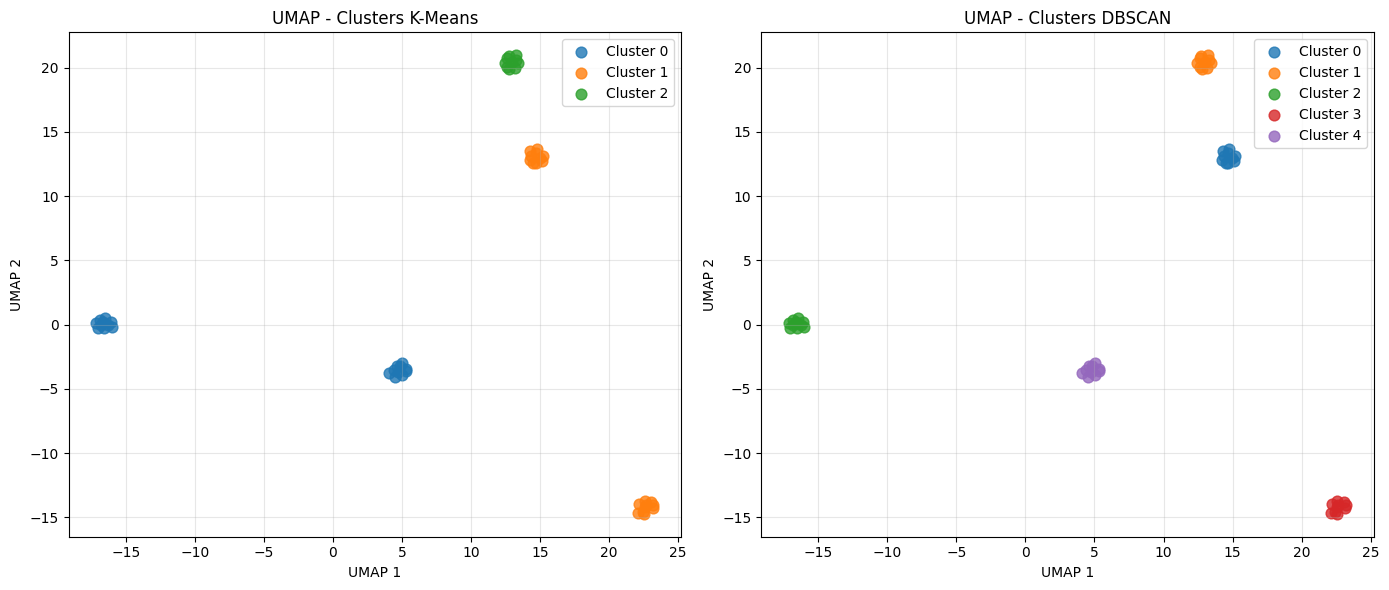

In [23]:
# =========================
# UMAP + gráficos comparativos
# K-Means vs DBSCAN
# =========================

# Si no tenés instalado UMAP, ejecutá una vez:
# !pip install umap-learn

import matplotlib.pyplot as plt
import umap.umap_ as umap

# =========================
# 1. Aplicar UMAP
# =========================

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.2,
    random_state=42
)

embedding = reducer.fit_transform(df_scaled)

chocolates["UMAP1"] = embedding[:, 0]
chocolates["UMAP2"] = embedding[:, 1]

# =========================
# 2. Graficar K-Means y DBSCAN juntos
# =========================

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# ---------
# K-Means
# ---------
for cluster, grupo in chocolates.groupby("Cluster"):
    axs[0].scatter(
        grupo["UMAP1"],
        grupo["UMAP2"],
        label=f"Cluster {cluster}",
        s=60,
        alpha=0.8
    )

axs[0].set_title("UMAP - Clusters K-Means")
axs[0].set_xlabel("UMAP 1")
axs[0].set_ylabel("UMAP 2")
axs[0].grid(alpha=0.3)
axs[0].legend()

# ---------
# DBSCAN
# ---------
for cluster, grupo in chocolates.groupby("Cluster_DBSCAN"):
    nombre = "Ruido" if cluster == -1 else f"Cluster {cluster}"

    axs[1].scatter(
        grupo["UMAP1"],
        grupo["UMAP2"],
        label=nombre,
        s=60,
        alpha=0.8
    )

axs[1].set_title("UMAP - Clusters DBSCAN")
axs[1].set_xlabel("UMAP 1")
axs[1].set_ylabel("UMAP 2")
axs[1].grid(alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

La representación mediante UMAP nos permite ver claramente la estrucutura del dataset. Vemos 5 grupos compactos y separados. DBSCAN identificó correctamente esas 5 regiones, K-Means las agrupó en 3 porque así nos sugirieron tanto el método del codo como el coeficiente de silueta que lo hagamos. 

# _Densidad_

Para profundizar en la interpretación de los clusters, hagamos un análisis sobre la distribución de las principales variables del conjunto de datos mediante la densidad. 

Primero, usamos la técnica de KDE. Esta permite estimar la distribución de un conjunto de datos de forma suave. 

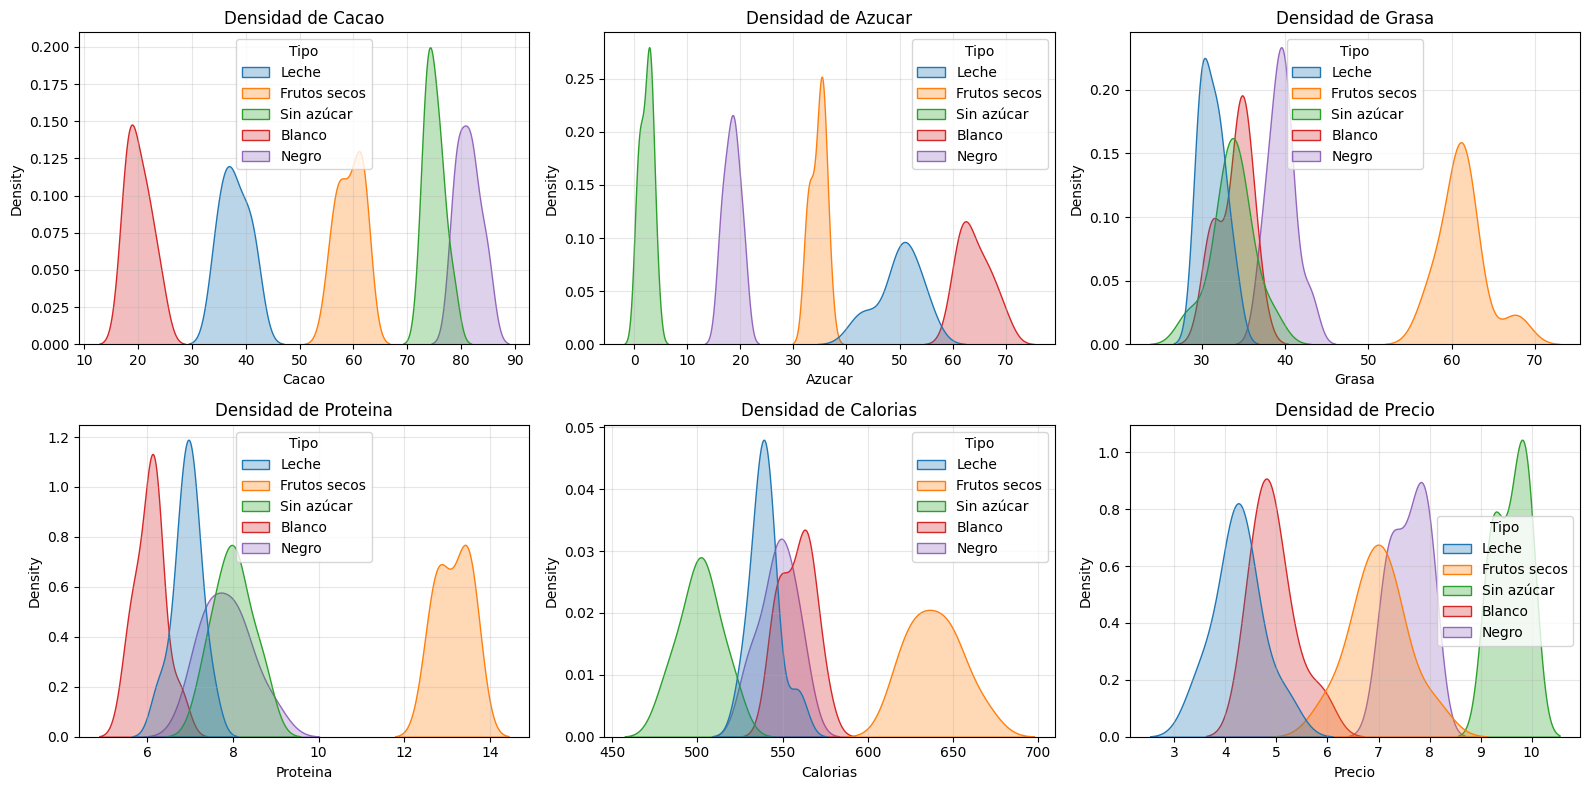

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ["Cacao", "Azucar", "Grasa",
             "Proteina", "Calorias", "Precio"]

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
axs = axs.flatten()

for i, var in enumerate(variables):
    sns.kdeplot(
        data=chocolates,
        x=var,
        hue="Tipo",
        fill=True,
        common_norm=False,
        alpha=0.3,
        ax=axs[i]
    )

    axs[i].set_title(f"Densidad de {var}")
    axs[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

En los gráficos anteriores, podemos ver como Cacao y Azúcar casi no tienen solapamientos; Grasa, Proteína y Calorías destacan claramente a los chocolates con frutos secos; y precio tiene mas superposición.

DBSCAN pudo recuperar las 5 categorías originales porque, en conjunto, hay 5 regiones bien definidas. Pero K-Means, al forzarlo con $k=3$, fusionó algunas categorías que si bien, son disitinguibles por algunas variables, están cerca cuando las consideramos todas. 

Ahora, trabajamos con la técnica de Isolation Forest. De esta manera, podemos identificar chocolates que, por su combinación de variables, se alejen del comportamiento general del conjunto de datos. 

Anomalia_IF
Normal     47
Anómalo     3
Name: count, dtype: int64
    ID      Cacao     Azucar      Grasa   Proteina    Calorias    Precio  \
1    2  55.455458  32.714059  67.705463  13.049124  648.155173  7.426217   
2    3  61.877002  34.106970  60.715575  13.342534  667.775903  6.634817   
24  25  57.428527  36.712798  61.121569  13.681339  617.592818  7.108229   

            Tipo  Cluster  Cluster_DBSCAN       PC1       PC2      UMAP1  \
1   Frutos secos        2               1  2.111465  2.974559  12.991533   
2   Frutos secos        2               1  1.912872  3.041344  12.452261   
24  Frutos secos        2               1  1.804566  2.491129  13.423138   

        UMAP2 Anomalia_IF  
1   20.470182     Anómalo  
2   20.341957     Anómalo  
24  20.345770     Anómalo  
Anomalia_IF   Anómalo  Normal
Tipo                         
Blanco              0      10
Frutos secos        3       7
Leche               0      10
Negro               0      10
Sin azúcar          0      10


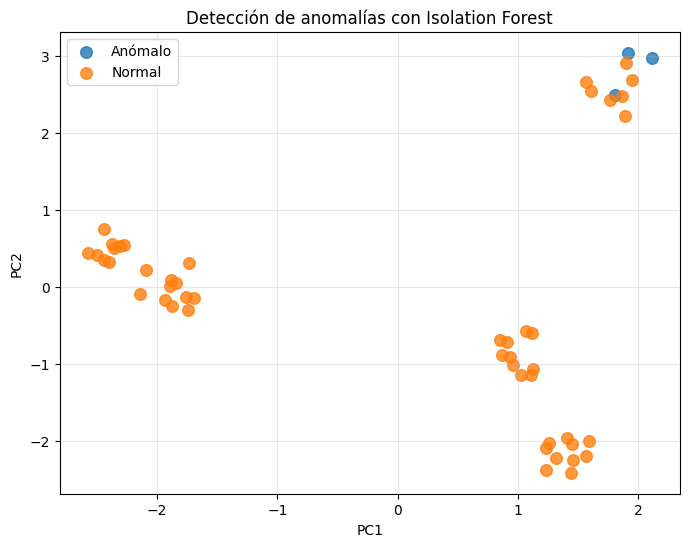

In [26]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import pandas as pd


iso = IsolationForest(
    contamination=0.05,   # esperamos aprox. 5% de anomalías
    random_state=42
)

chocolates["Anomalia_IF"] = iso.fit_predict(df_scaled)

# En Isolation Forest:
#  1  = observación normal
# -1  = anomalía

chocolates["Anomalia_IF"] = chocolates["Anomalia_IF"].map({
    1: "Normal",
    -1: "Anómalo"
})



print(chocolates["Anomalia_IF"].value_counts())


anomalias = chocolates[chocolates["Anomalia_IF"] == "Anómalo"]

print(anomalias)


print(pd.crosstab(chocolates["Tipo"], chocolates["Anomalia_IF"]))


plt.figure(figsize=(8,6))

for estado, grupo in chocolates.groupby("Anomalia_IF"):
    plt.scatter(
        grupo["PC1"],
        grupo["PC2"],
        label=estado,
        s=70,
        alpha=0.8
    )

plt.title("Detección de anomalías con Isolation Forest")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El algoritmo de Isolation Forest encontró 3 anomalías. Todas ellas pertenecientes a los chocolates con frutos secos, que se caracterizan por altos valores de grasa, proteína y calorías. Este resultado nos dice que dichas observaciones representan los caso más extremos del conjunto de datos, pero no son errores o valores atípicos dentro de su categoría. 

# _Autoencoders_

Tras haber analizado la representación del conjunto de datos mediante PCA y UMAP, damos un paso más e incorporamos un tercer enfoque de reducción de dimensionalidad, los Autoencoders.

PCA, una técnica lineal, nos permitió encontrar las direcciones que explican la mayor parte de la variabilidad de los datos. UMAP, técnica no lineal, nos facilitó la visualización de los clusters, intentando preservar la estructura de la vecindad. 

Ahora, los autoencoders, tendrán como objetivo comprimir las 6 variables numéricas  en una representación de dos dimensiones de una forma distinta: Aprenden automáticamente una representación comprimida de los datos mediante el entrenamiento de una red neuronal. Para esto, necesitamos un encoder y un decoder. 

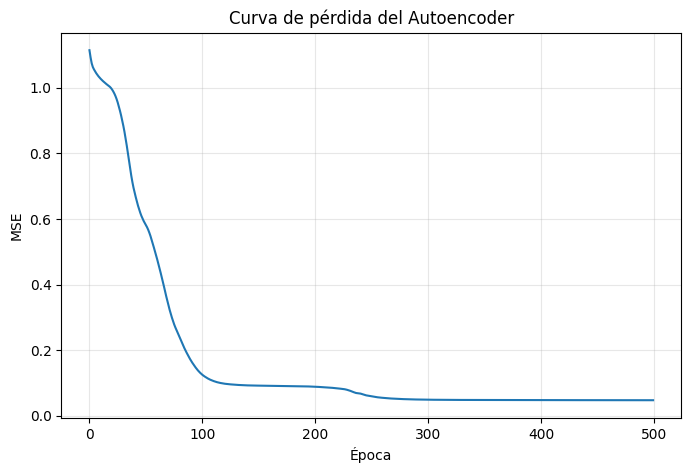

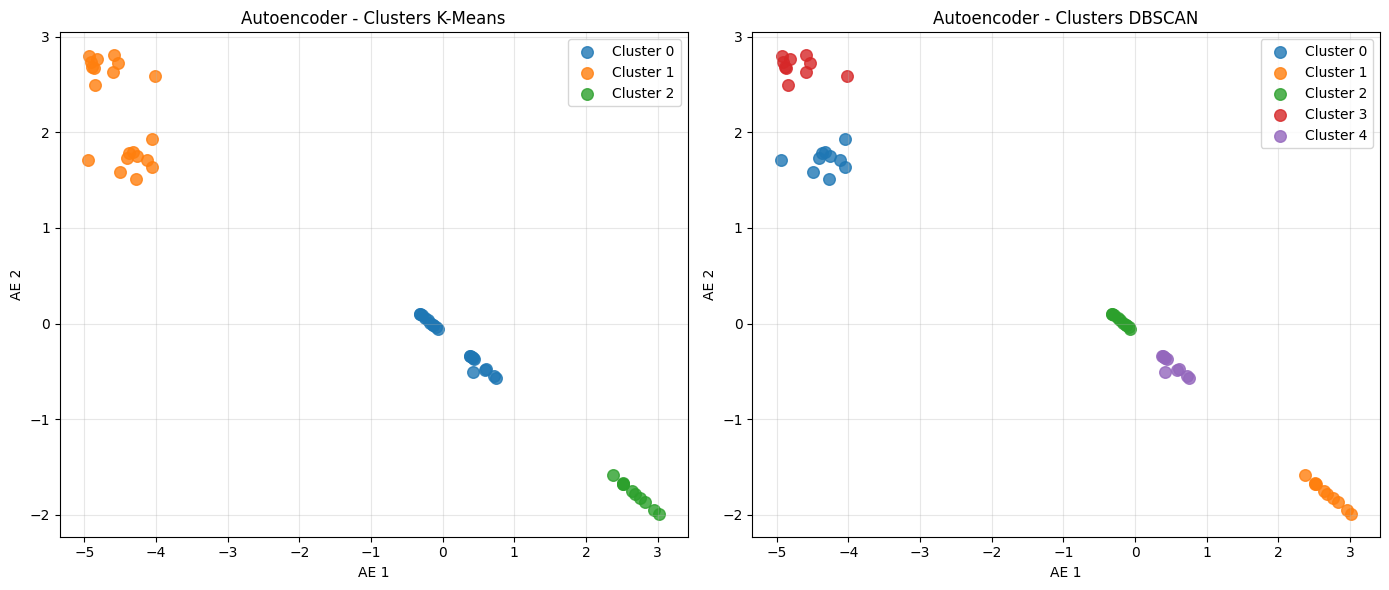

(50, 2)
(50, 2)


In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Preparar datos
# =========================
X = df_scaled.to_numpy()
X_tensor = torch.tensor(X, dtype=torch.float32)

input_dim = X_tensor.shape[1]   # 6 variables
latent_dim = 2                  # representación latente 2D

# =========================
# 2. Definir Autoencoder
# =========================

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.ReLU(),
            nn.Linear(4, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 4),
            nn.ReLU(),
            nn.Linear(4, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_reconstruido = self.decoder(z)
        return x_reconstruido

autoencoder = Autoencoder(input_dim, latent_dim)

# =========================
# 3. Entrenar
# =========================

criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.01)

epochs = 500
losses = []

for epoch in range(epochs):
    autoencoder.train()
    
    optimizer.zero_grad()
    
    salida = autoencoder(X_tensor)
    loss = criterion(salida, X_tensor)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

# =========================
# 4. Curva de pérdida
# =========================

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Curva de pérdida del Autoencoder")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.grid(alpha=0.3)
plt.show()

# =========================
# 5. Obtener representación latente
# =========================

autoencoder.eval()

with torch.no_grad():
    Z = autoencoder.encoder(X_tensor).numpy()

chocolates["AE1"] = Z[:, 0]
chocolates["AE2"] = Z[:, 1]

# =========================
# 6. Graficar representación latente
# =========================

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
for cluster, grupo in chocolates.groupby("Cluster"):
    axs[0].scatter(
        grupo["AE1"],
        grupo["AE2"],
        label=f"Cluster {cluster}",
        s=70,
        alpha=0.8
    )

axs[0].set_title("Autoencoder - Clusters K-Means")
axs[0].set_xlabel("AE 1")
axs[0].set_ylabel("AE 2")
axs[0].legend()
axs[0].grid(alpha=0.3)

# DBSCAN
for cluster, grupo in chocolates.groupby("Cluster_DBSCAN"):
    axs[1].scatter(
        grupo["AE1"],
        grupo["AE2"],
        label=f"Cluster {cluster}",
        s=70,
        alpha=0.8
    )

axs[1].set_title("Autoencoder - Clusters DBSCAN")
axs[1].set_xlabel("AE 1")
axs[1].set_ylabel("AE 2")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(Z.shape)
print(chocolates[["AE1", "AE2"]].shape)

La curva de pérdida muestra que el autoencoder aprende progresivamente a reconstruir las observaciones del conjunto de datos. Al principio, la pérdida era alta y disminuye rápidamente. Al avanzar el entrenamiento, la pérdida se estabiliza, sugiriendo que el modelo ha convergido y la representación es estable.

La representación latente evidencia que la red logró condensar las 6 variables originales en 2 dimensiones. En la visualización de K-Means, se distinguen los 3 clusters obtenidos previamente y en la de DBSCAN, vuelven a verse las 5 categoría originales.

# _Conclusiones_

Empezamos este trabajo construyendo un dataset de distintos tipos de chocolate, caractizados por sus variables nutricionales y comerciales. 

Primero, comenzamos haciendo un pequeño análisis exploratorio. Vimos algunas estadísticas descriptivas y vimos como se relacionaban algunos pares de variables entre sí. 

Pasamos al clustering. Usamos dos modelos: K-Means y DBSCAN. Para trabajar con K-Means, utilizamos el método del codo y coeficiente de silueta. Ambos sugirieron usar un número más pequeño de la cantidad original de categorías para agrupar los datos. Al usar DBSCAN, que trabaja sin fijar la cantidad de clusters, llegamos a las 5 clases originales. 

Para visualizar los resultados, usamos técnicas que permiten reducir las dimensiones. PCA permitió obtener una representación lineal de los datos e interpretar el aporte de cada variable mediante el análisis de los loadings. UMAP nos dió una representación no lineal que preservó la estructura de vecindad entre observaciones, mostrando la clara separación entre distintos grupos. Y por últimos, el Autoencoder aprendió una representación latente de dos dimensiones mediante una red neuronal, dando resultados consistentes a lo ya observado.

Estudiamos las distribuciones de las variables usando KDE, lo que permitió comprender cuales variables eran las responsables de la formación de grupos. E

También usamos Isolation Forest para detectar posibles anomalías dentro del conjunto de datos. El algoritmo identificó tan solo 3 observaciones anómalas pertenecientes al conjunto de los chocolates con frutos secos, lo que resulta coherente a las características extremas de la categoría.

En resumen, podemos concluir que las distintas técnicas de aprendizaje no supervisado son complementarias entre sí: los algoritmos de clustering nos permiten agrupar observaciones con características similares, las técnicas de reudcción de dimensionalidad facilitan su interpretación visual y los métodos de densidad nos permiten explicar cuales variables fuerzan esas agrupaciones. 